# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('681_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.700187,0.124546,0.010521,0.155778,0.008968
1,no,0.832701,0.125651,0.000000,0.000000,0.041647
2,no2,0.189708,0.765346,0.004966,0.042398,-0.002417
3,o3,0.955207,0.000000,0.000000,0.047491,-0.002698
4,bin0,0.000010,0.084696,0.000000,0.938811,-0.023517
5,bin1,0.000000,0.000000,0.482869,0.635336,-0.118206
6,bin2,0.000000,0.000000,0.757314,0.357012,-0.114326
7,bin3,0.000000,0.000000,0.843892,0.169947,-0.013839
8,bin4,0.222292,0.080669,0.697739,0.000000,-0.000700
9,bin5,0.336554,0.135436,0.533153,0.000000,-0.005142


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.700187
1,no,Factor 1,0.832701
2,no2,Factor 1,0.189708
3,o3,Factor 1,0.955207
4,bin0,Factor 1,0.000010
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.000000
8,bin4,Factor 1,0.222292
9,bin5,Factor 1,0.336554


In [5]:
#load in the timeseries data
ts = pd.read_csv('MOD-000681_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('681_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-03-31 20:00:00,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664,0.499204,0.470705,0.000507,0.656074,0.052060,0.085512,0.099961
1,2025-03-31 21:00:00,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657,0.484861,0.476657,0.000703,0.575898,0.051292,0.073015,0.128371
2,2025-03-31 22:00:00,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467,0.426520,0.531629,0.000734,0.372281,0.054611,0.041815,0.115849
3,2025-03-31 23:00:00,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489,0.341533,0.720238,0.000711,0.208995,0.076346,0.017071,0.039033
4,2025-04-01 00:00:00,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891,0.317863,0.748833,0.000698,0.140064,0.078989,0.006683,0.033827


In [6]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664,0.499204,0.470705,0.000507,0.656074,0.052060,0.085512,0.099961
2025-03-31 21:00:00,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657,0.484861,0.476657,0.000703,0.575898,0.051292,0.073015,0.128371
2025-03-31 22:00:00,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467,0.426520,0.531629,0.000734,0.372281,0.054611,0.041815,0.115849
2025-03-31 23:00:00,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489,0.341533,0.720238,0.000711,0.208995,0.076346,0.017071,0.039033
2025-04-01 00:00:00,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891,0.317863,0.748833,0.000698,0.140064,0.078989,0.006683,0.033827
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 20:00:00,0.045087,0.024703,0.014011,0.009709,0.011211,0.021898,0.382941,0.489262,0.000540,0.317771,0.053346,0.037477,0.001067
2025-12-27 21:00:00,0.047395,0.027205,0.015762,0.011650,0.011211,0.021898,0.360894,0.483543,0.000640,0.414080,0.052102,0.051065,0.001927
2025-12-27 22:00:00,0.047435,0.029081,0.014594,0.009709,0.011211,0.021898,0.330928,0.506303,0.000530,0.354681,0.054168,0.042082,0.002624


In [7]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3
timestamp_local,,,,,,,,,,,,,
2025-03-31,0.110331,0.129456,0.075306,0.074272,0.113789,0.306569,0.438029,0.549807,0.000664,0.453312,0.058577,0.054353,0.095804
2025-04-01,0.025550,0.018983,0.010435,0.007929,0.009623,0.020681,0.315207,0.675474,0.000586,0.158458,0.073238,0.011721,0.005196
2025-04-02,0.024101,0.021146,0.021210,0.024110,0.036342,0.094891,0.377276,0.690710,0.000538,0.322150,0.075573,0.034941,0.023484
2025-04-03,0.093889,0.082030,0.053196,0.062136,0.105288,0.289538,0.433108,0.517298,0.000550,0.387487,0.056202,0.046186,0.081549
2025-04-04,0.021705,0.012742,0.009146,0.009061,0.013920,0.034063,0.343864,0.594300,0.000535,0.235323,0.065455,0.024399,0.005744


## Setting Up Barchart and 6-month Figures

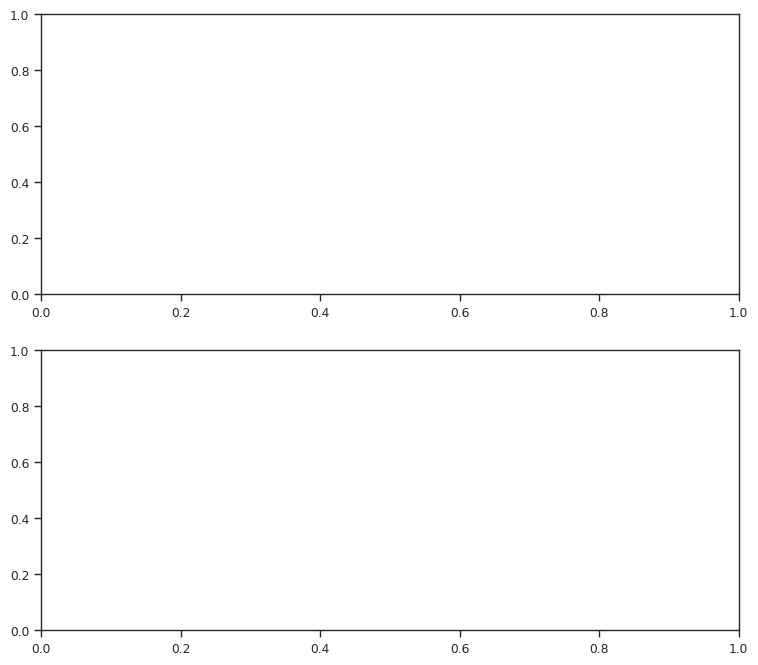

In [8]:
# set up the figure
fig = plt.figure(figsize=(9, 8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [9]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [10]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipykernel_3093/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [11]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [12]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [13]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[-180], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [14]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [15]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00397',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [22]:
import os

# Create the directory if it doesn't exist
os.makedirs('MOD-00681', exist_ok=True)

fig.savefig('MOD-00681/time_barchart_MOD-000681_4_factor.png')

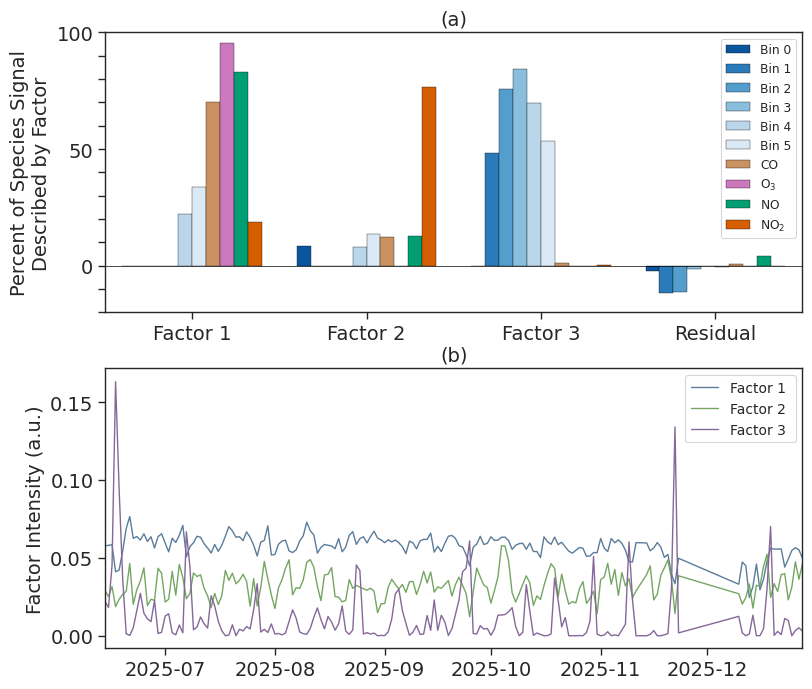

In [17]:
fig

## Setting Up Diurnal Figure

In [18]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-03-31 20:00:00,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664,0.499204,0.470705,0.000507,0.656074,0.052060,0.085512,0.099961
1,2025-03-31 21:00:00,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657,0.484861,0.476657,0.000703,0.575898,0.051292,0.073015,0.128371
2,2025-03-31 22:00:00,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467,0.426520,0.531629,0.000734,0.372281,0.054611,0.041815,0.115849
3,2025-03-31 23:00:00,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489,0.341533,0.720238,0.000711,0.208995,0.076346,0.017071,0.039033
4,2025-04-01 00:00:00,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891,0.317863,0.748833,0.000698,0.140064,0.078989,0.006683,0.033827


In [19]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Hour
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664,0.499204,0.470705,0.000507,0.656074,0.052060,0.085512,0.099961,20
2025-03-31 21:00:00,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657,0.484861,0.476657,0.000703,0.575898,0.051292,0.073015,0.128371,21
2025-03-31 22:00:00,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467,0.426520,0.531629,0.000734,0.372281,0.054611,0.041815,0.115849,22
2025-03-31 23:00:00,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489,0.341533,0.720238,0.000711,0.208995,0.076346,0.017071,0.039033,23
2025-04-01 00:00:00,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891,0.317863,0.748833,0.000698,0.140064,0.078989,0.006683,0.033827,0


In [20]:
#grouping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3
Hour,,,
00:00,0.057890,0.033816,0.020113
01:00,0.056797,0.034123,0.020034
02:00,0.056013,0.032255,0.019265
03:00,0.054852,0.031561,0.019346
04:00,0.053497,0.032586,0.020591
05:00,0.051913,0.033712,0.021839
06:00,0.051151,0.033863,0.021633
07:00,0.052012,0.029947,0.018877
08:00,0.053790,0.023819,0.016338


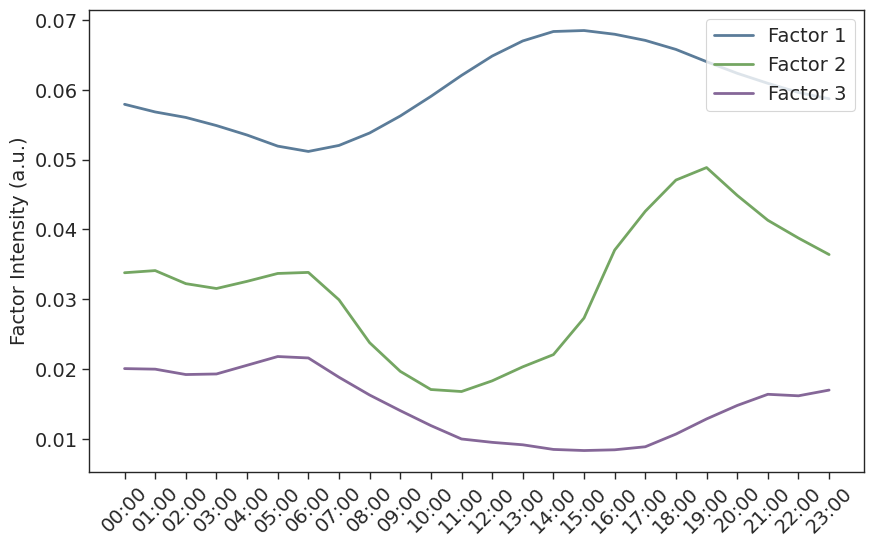

In [21]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

plt.savefig('MOD-00681/diurnal_MOD-000681_4_factor.png')
plt.show()